In [1]:
import numpy as np
import matplotlib.pyplot as plt

L = 60e-3       # m, longitud braços
m = 8.0         # kg, massa 
zeta = 0.15     # amortiment relatiu (damping ratio)
f = 10.0        # Hz, freqüència límit

# Moviment de la base:  y(t)=y0*sin(2*pi*f*t))
y0 = 0.5e-3     # m, amplitud del moviment de la base
fd = 30.0/2.0   # Hz, freqüència moviment de la base

In [ ]:
omega = 2 * np.pi * f
omega_n = omega / np.sqrt(2)
k = omega_n 
** 2 * m

In [3]:
ce = zeta * 2.0 * np.sqrt(k * m)  # equivalent c_eq
c = 4.0 * ce  # actual c in the original mechanical layout

In [4]:
omega_base = 2 * np.pi * fd
Omegad = omega_base / omega_n

# SENSE DAMPING:  HB = |X/Y| i psiB = fase entre x(t) i y(t)
HB = 1.0 / np.sqrt((1.0 - Omegad ** 2) ** 2)
# undamped phase: 0 or pi depending on Omegad
psiB_eff = np.pi if Omegad > 1 else 0.0

# AMB DAMPING:  HA = |X/Y| i psiA = fase entre x(t) i y(t)
# Frequency response magnitudes and phases
HA = np.sqrt(1.0 + (2.0 * zeta * Omegad) ** 2) / np.sqrt((1.0 - Omegad ** 2) ** 2 + (2.0 * zeta * Omegad) ** 2)

num = 2.0 * zeta * Omegad ** 3
den = 1.0 + Omegad ** 2 * (4.0 * zeta ** 2 - 1.0)
psiA = np.arctan2(num, den)  # arctan2  per obtenir el quadrant correcte

# if Omegad > 1 convenció de signes per a la fase:  psiA_eff = psiA + pi
if Omegad > 1:
    psiA_eff = psiA + np.pi
else:
    psiA_eff = psiA

In [5]:
print("\nParàmetres del sistema:")
print("-" * 50)
print(f" L:                 {L:.1f} m")
print(f" m:                 {m:.1f} kg")
print(f" zeta:              {zeta:.3f}")
print(f" omega ({f:.0f} Hz):     {omega:.3f} rad/s")
print(f" omega_n (natural): {omega_n:.3f} rad/s")
print(f" k:                 {k :.0f} N/m")
print(f" c_equ.:            {ce:.1f} Ns/m")
print(f" c (sistema):       {c :.1f} Ns/m")
print("-" * 50)
print("\nResposta estacionaria (mov. de la base):")
print("-" * 50)
print(f" omega ({fd:.0f} Hz):     {omega_base:.3f} rad/s")
print(f" Omega (r):         {Omegad:.3f}\n")
print(f" HB (no esmorteït): {HB:.3f}")
print(f" psiB (no esmort.): {psiB_eff:.3f} rad ({np.degrees(psiB_eff):.1f} deg)\n")
print(f" HA (esmorteït):    {HA:.3f}")
print(f" psiA (esmorteït):  {psiA_eff:.3f} rad ({np.degrees(psiA_eff):.1f} deg)")
print("-" * 50)


Paràmetres del sistema:
--------------------------------------------------
 L:                 0.1 m
 m:                 8.0 kg
 zeta:              0.150
 omega (10 Hz):     62.832 rad/s
 omega_n (natural): 44.429 rad/s
 k:                 15791 N/m
 c_equ.:            106.6 Ns/m
 c (sistema):       426.5 Ns/m
--------------------------------------------------

Resposta estacionaria (mov. de la base):
--------------------------------------------------
 omega (15 Hz):     94.248 rad/s
 Omega (r):         2.121

 HB (no esmorteït): 0.286
 psiB (no esmort.): 3.142 rad (180.0 deg)

 HA (esmorteït):    0.333
 psiA (esmorteït):  5.537 rad (317.2 deg)
--------------------------------------------------


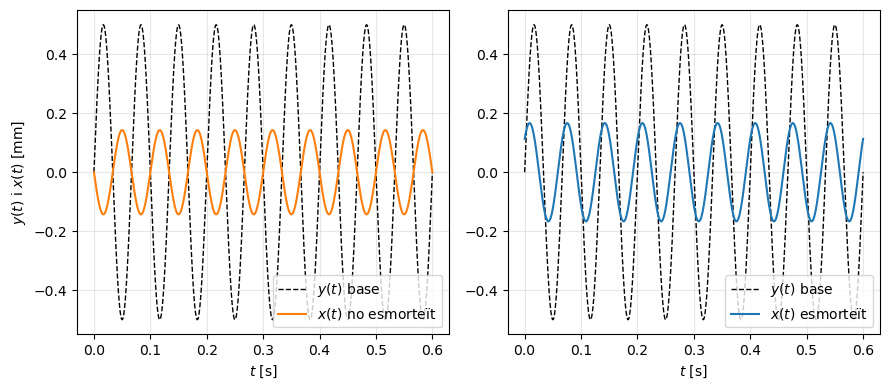

In [6]:
period = 2.0 * np.pi / omega_base
t = np.linspace(0.0, 9.0 * period, 4000)

y_base =     y0 * np.sin(omega_base * t)
x_damped =   y0 * HA * np.sin(omega_base * t - psiA_eff)
x_undamped = y0 * HB * np.sin(omega_base * t - psiB_eff)

fig, axs = plt.subplots(1, 2, sharex=True, figsize=(9, 4))

axs[0].plot(t, y_base * 1e3, '--', label=r'$y(t)$ base', color='k', lw=1)
axs[0].plot(t, x_undamped * 1e3, label=r'$x(t)$ no esmorteït', color='C1')
axs[0].set_xlabel(r'$t$ [s]')
axs[0].set_ylabel(r'$y(t)$ i $x(t)$ [mm]')
axs[0].legend(loc='lower right')
axs[0].grid(alpha=0.3)

axs[1].plot(t, y_base * 1e3, '--', label=r'$y(t)$ base', color='k', lw=1)
axs[1].plot(t, x_damped * 1e3, label=r'$x(t)$ esmorteït', color='C0')
axs[1].set_xlabel(r'$t$ [s]')
axs[1].legend(loc='lower right')
axs[1].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('CME_Exemple_7_4_SOL.pdf')